# Homogeneous Square

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source
from ttnte.cad import Patch
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Material": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        }
    }
)

In [3]:
# Create NURBS geometry
length = 10 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patch = Patch(cad.bilinear(points), "Material")

# Add uniform source of 1/cm to patch
source = IsotropicInternalSource(np.ones((1, *patch.shape)))
patch.set_source(source)

# Create mesh
mesh = IGAMesh(max_processes=32)
mesh.add_patch(patch)

# Refine mesh resolution
mesh.refine(factor=21, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Material, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7e8f787875c0>, id=0, name=None, shape=(24, 24), backend=geomdl)

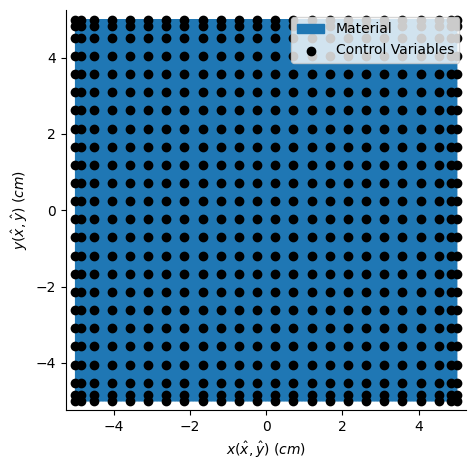

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

## Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 24, B = 24
Operators: H, S, q, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

Process ForkProcess-25:
Traceback (most recent call last):
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/concurrent/futures/process.py", line 252, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/multiprocessing/queues.py", line 103, in get
    res = self._recv_bytes()
          ^^^^^^^^^^^^^^^^^^
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/multiprocessing/connection.py", line 43

KeyboardInterrupt: 

## Solve

In [ ]:
# Run fixed source calculation
psi = fixed_source(
    T=LinearOperator([tts.H, mats.B_out, -tts.S], N=assembler.N, M=assembler.M),
    q=mats.q,
    device=0,
    max_iters=50,
    tol=1e-10,
    restarts=250,
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi.unsqueeze(3))

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

## Plotting and Comparison to OpenMC

In [ ]:
leakage_frac_openmc = [0.42095701399999963, 2.2038687252709062e-05]
phi_mc = np.load("./openmc/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/data/mesh_stdev.npy")

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = float(leakage / production)
print(f"TIDG leakage fraction = {leakage_frac}")
print(f"OpenMC leakage fraction = {leakage_frac_openmc[0]} +/- {leakage_frac_openmc[1]}")
print(f"TIDG is {(leakage_frac - leakage_frac_openmc[0]) / leakage_frac_openmc[1]} stdevs from OpenMC")

In [ ]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(6, 6))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()

In [ ]:
# Regular mesh
X, Y = np.meshgrid(
    np.linspace(-5, 5, phi_mc.shape[1]),
    np.linspace(-5, 5, phi_mc.shape[2]),
)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(
        X, Y, (phi_avg[g,] - phi_mc[g,]) / phi_mc_stdev[g,], cmap="plasma"
    )
    divider = make_axes_locatable(ax)

    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label("$\\frac{\\phi^{TIDG}_{g} - \\phi^{MC}_{g}}{\\sigma^{MC}}$", size=14)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)